In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivam2503/diamonds/diamonds.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_theme(context='notebook',
    style='darkgrid',
    palette='deep',
    font='sans-serif',
    font_scale=1,
    color_codes=True,
    rc=None,)

In [4]:
df=pd.read_csv("/kaggle/input/datasets/shivam2503/diamonds/diamonds.csv")

In [5]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [7]:
df.drop(columns=["Unnamed: 0"],inplace=True)

In [8]:
df.duplicated().sum()

np.int64(146)

In [9]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [10]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [11]:
df.describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


# EDA(Exploratory Data Analysis)

<Axes: >

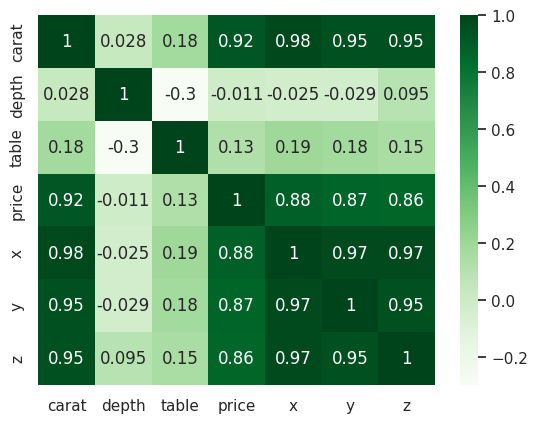

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Greens')

<Axes: xlabel='price', ylabel='carat'>

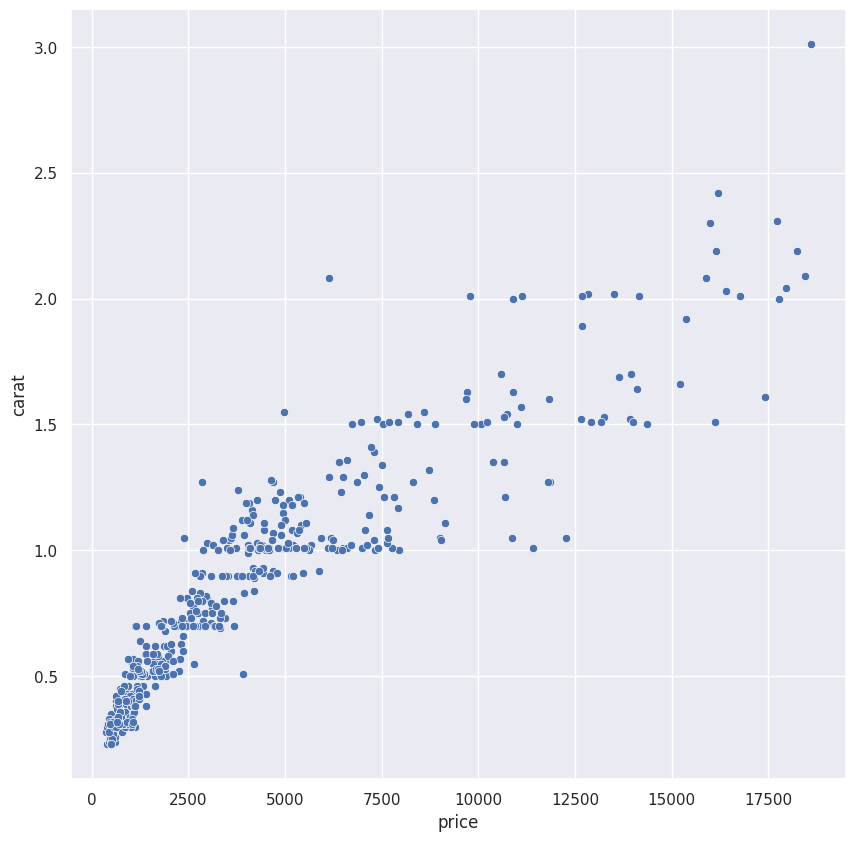

In [13]:
plt.figure(figsize=(10,10))
sns.scatterplot(x='price',y='carat',data=df.sample(500))

There is a direct strong releation between carat of diamond and its price. There are some anamolies which could be due to color and cut of diamond.

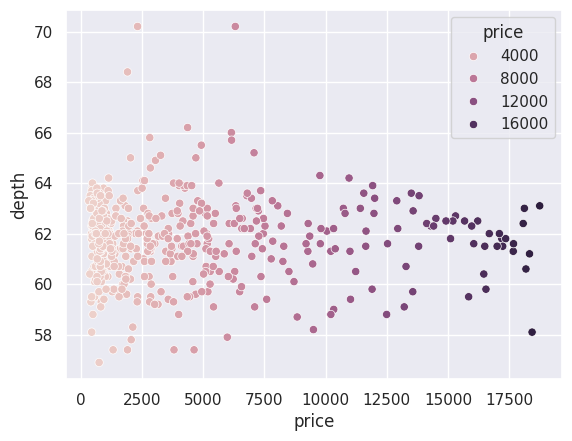

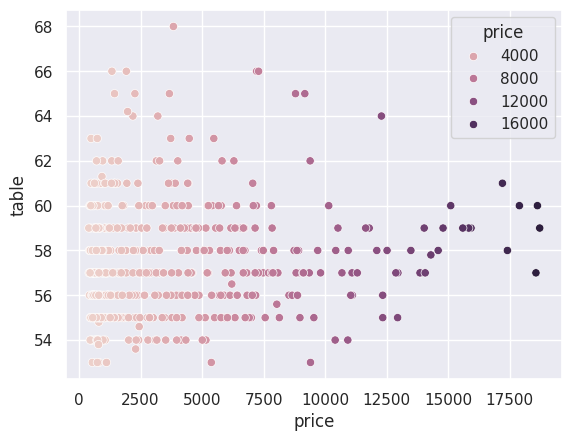

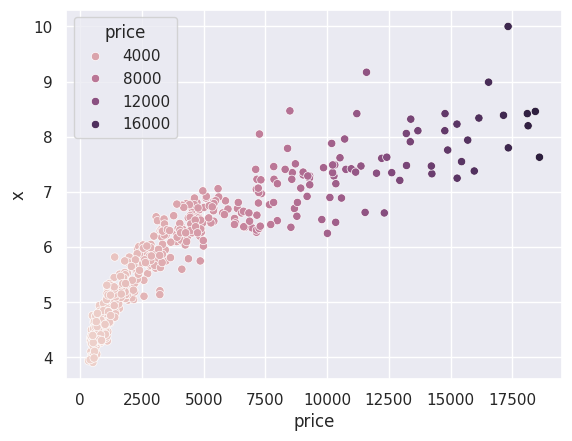

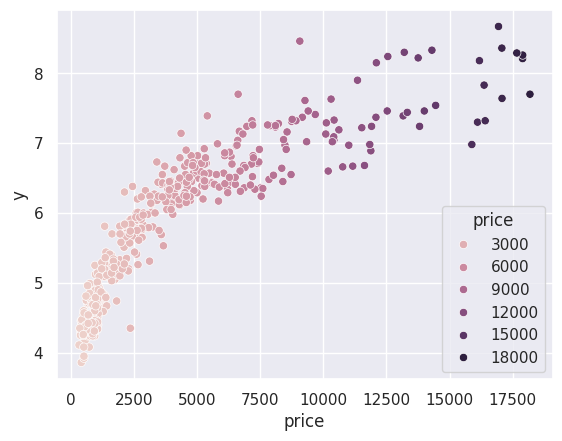

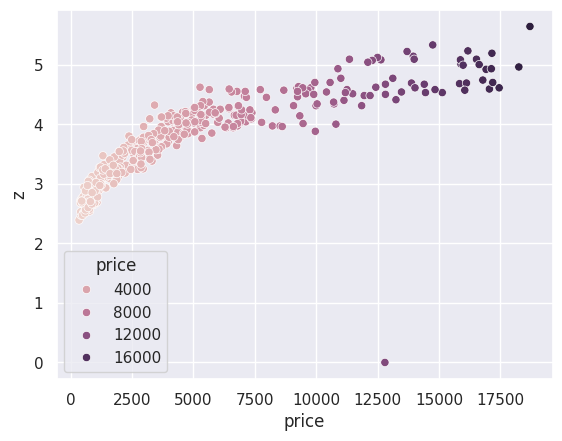

In [14]:
columns=['depth', 'table','x', 'y', 'z']
for col in columns:
    sns.scatterplot(x='price',y=col,data=df.sample(500),hue='price')
    plt.show()

This suggest a strong releation between price ,x,y and z dimension of diamond.

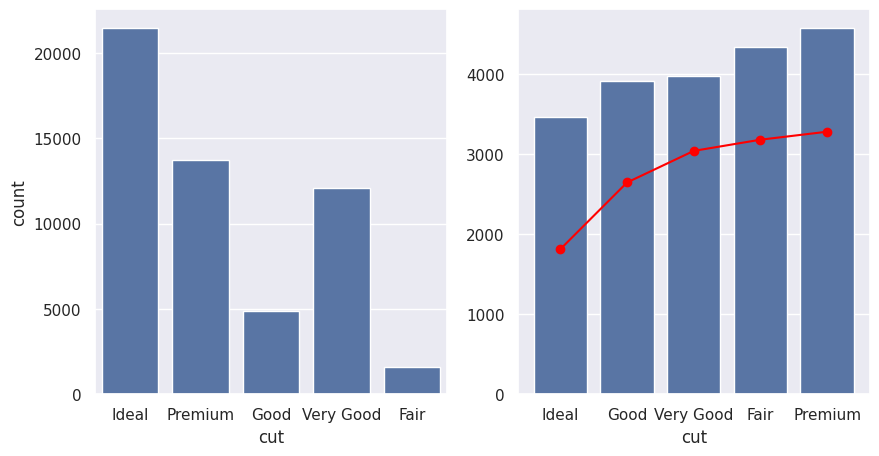

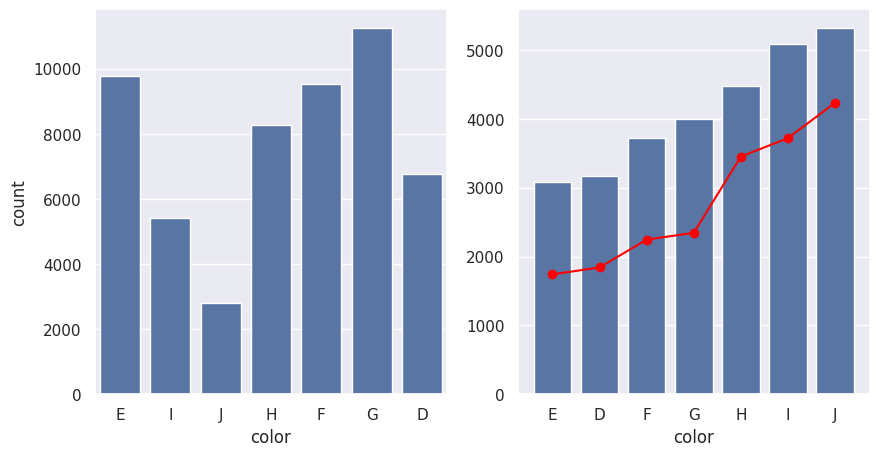

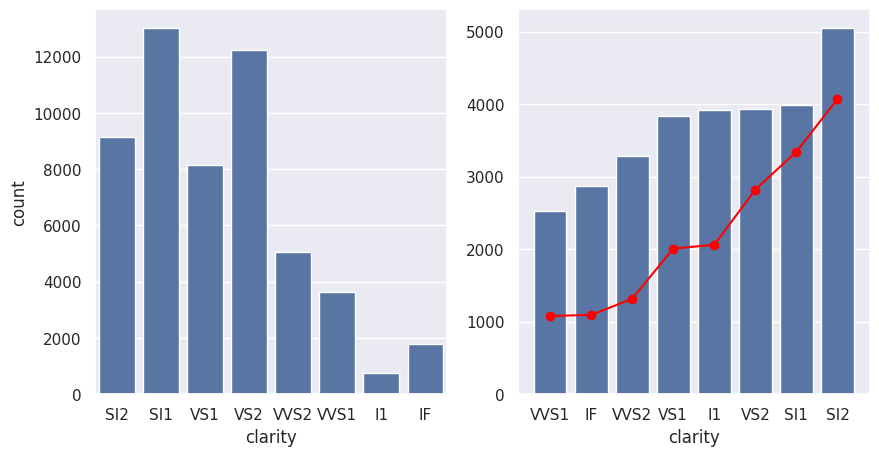

In [15]:
cat_columns=['cut', 'color', 'clarity']
for col in cat_columns:
    plt.figure(figsize=(10,5))
    a=df.groupby(col)['price'].mean().sort_values(ascending=True)
    plt.subplot(1,2,1)
    sns.countplot(x=df[col])
    plt.subplot(1,2,2)
    sns.barplot(x=a.index,y=a.values)
    plt.plot(df.groupby(col)['price'].median().sort_values(ascending=True).values,
            color="red",marker="o")
    plt.show()
    

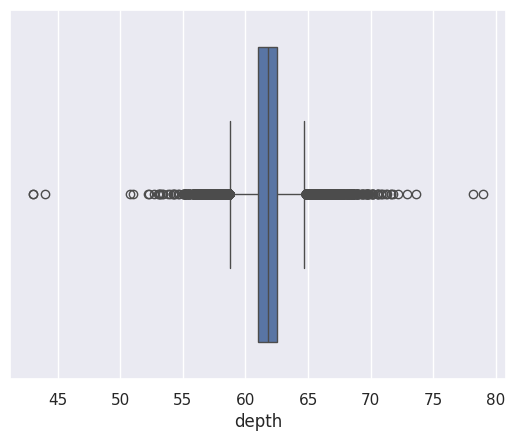

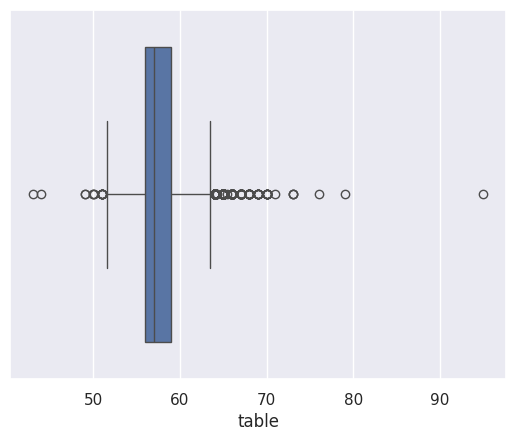

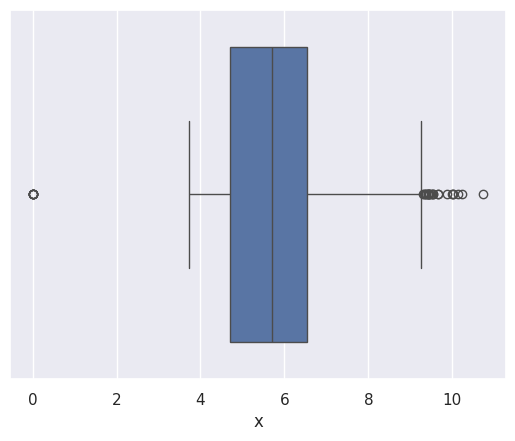

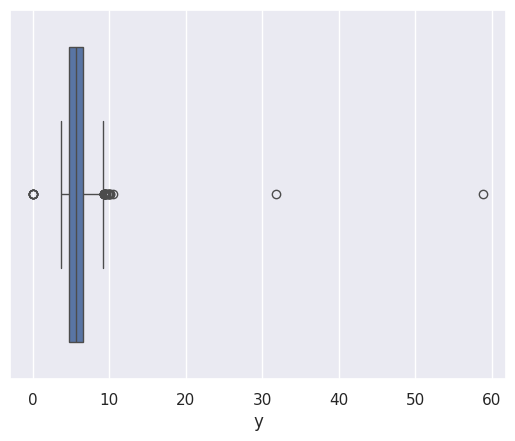

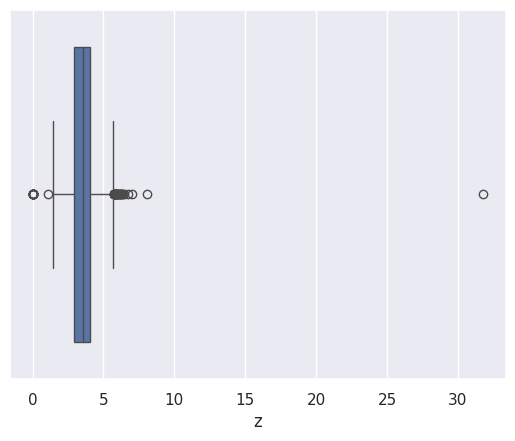

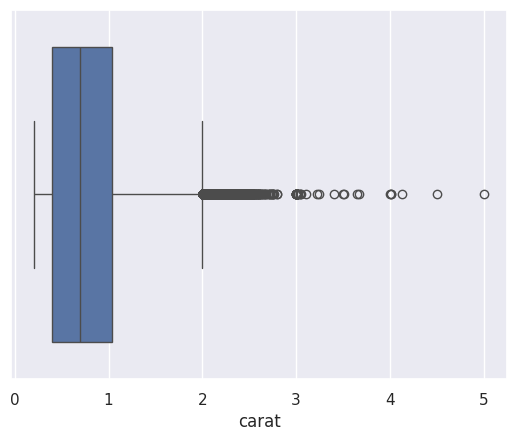

In [16]:
columns.append("carat")
for col in columns:
    sns.boxplot(x=df[col])
    plt.show()

there are so many outliers in all the x,y,z ,carat etc but these are also justifyable,Some diamonds are usually very big because of that all these parameters can have these ouliers.

<Axes: xlabel='price'>

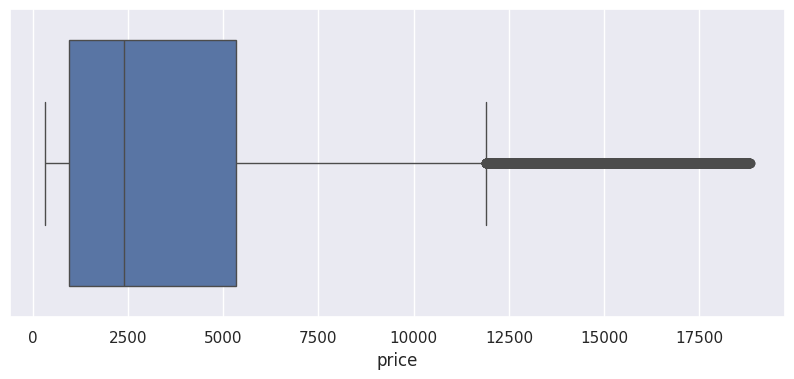

In [17]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['price'])

In [18]:
train=df.drop(columns='price',axis=1)
target=df['price']

In [19]:
train=pd.get_dummies(train,drop_first=True)

# Required modules

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [21]:
x_train,x_test,y_train,y_test=train_test_split(train,target,test_size=0.33,random_state=42)

In [22]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [23]:
model=LinearRegression()
model.fit(x_train_scaled,y_train)

LinearRegression()

In [24]:
y_pred=model.predict(x_test_scaled)

In [25]:
print(f"Train R² : {model.score(x_train_scaled, y_train):.4f}")
print(f"Test R² : {model.score(x_test_scaled, y_test):.4f}")
print(f"prediction of by: {mean_absolute_error(y_test,y_pred):.4f} USD")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} USD")

Train R² : 0.9201
Test R² : 0.9195
prediction of by: 735.1785 USD
RMSE: 1114.54 USD


In [26]:
models={"Ridge":Ridge(alpha=10.0),"Lasso":Lasso(alpha=1.0)}
for name,model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred=model.predict(x_test_scaled)
    print("="*50)
    print(f"model:{name}")
    print(f"Train R² : {model.score(x_train_scaled, y_train):.4f}")
    print(f"Test R² : {model.score(x_test_scaled, y_test):.4f}")
    print(f"prediction of by: {mean_absolute_error(y_test,y_pred):.4f} USD")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} USD")
    

model:Ridge
Train R² : 0.9201
Test R² : 0.9194
prediction of by: 735.8712 USD
RMSE: 1114.79 USD
model:Lasso
Train R² : 0.9200
Test R² : 0.9194
prediction of by: 734.7783 USD
RMSE: 1115.09 USD


In [27]:
models={
    "desicion_tree":DecisionTreeRegressor(random_state=42),
    "Random_forest":RandomForestRegressor(n_estimators=150,n_jobs=-1,random_state=42)
}
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print("="*50)
    print(f"model:{name}")
    print(f"Train R² : {model.score(x_train, y_train):.4f}")
    print(f"Test R² : {model.score(x_test, y_test):.4f}")
    print(f"prediction of by: {mean_absolute_error(y_test,y_pred):.4f} USD")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} USD")

model:desicion_tree
Train R² : 1.0000
Test R² : 0.9556
prediction of by: 379.3993 USD
RMSE: 827.67 USD
model:Random_forest
Train R² : 0.9963
Test R² : 0.9738
prediction of by: 294.7590 USD
RMSE: 635.69 USD


* decision tree is suggesting of overfitting.
* Random forest is doing well. 

In [28]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [29]:
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(f"Train R² : {model.score(x_train, y_train):.4f}")
print(f"Test R² : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Train R² : 0.9832
Test R² : 0.9765
MAE : 305.69
RMSE : 601.70


# Conclusion

* **Data was very clear to analyse price is directly dependent on the shape,size of diamond,  carat also quality of diamond.**

* **models trained like linear regression,decision tree regressor,random forest ridge ,lasso also xgboost.**
* **among all the models our xgboost is concluded to be best with best r2 score and least errors in predictions.**

In [30]:
import joblib
joblib.dump(model,'model.pkl')

['model.pkl']

In [ ]:
x.columns.tolist()